# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/b7e925173644493a63480af913fba68aedad83ef/15.%20Clustering/data/EastWestAirlines.xlsx"
excel_file = pd.ExcelFile(url)

In [3]:
print(excel_file.sheet_names)

['Description', 'data']


In [4]:
df = pd.read_excel(excel_file,sheet_name = "data")

# Preview the Dataset

In [5]:
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


# Initial Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


## Dataset Dimensions

In [7]:
print("Shape : ",df.shape)
print("Size : ",df.size)

Shape :  (3999, 12)
Size :  47988


## Checking DataTypes

In [8]:
df.dtypes

,0
ID#,int64
Balance,int64
Qual_miles,int64
cc1_miles,int64
cc2_miles,int64
cc3_miles,int64
Bonus_miles,int64
Bonus_trans,int64
Flight_miles_12mo,int64
Flight_trans_12,int64


## Observation:

The dataset contains **3999 records and 12 columns**. All features are stored as numerical data types and there are no missing values or duplicate records in the dataset.

The dataset contains customer-related information such as account balance, mileage activity, bonus miles, flight activity, enrolment duration, and award status.

# Data Cleaning

## Checking Duplicate Records and Missing Values

In [9]:
print("No.of Duplicate Records : ",df.duplicated().sum())
print("="*50)
print("NO.of Null Values : ")
print(df.isnull().sum())

No.of Duplicate Records :  0
NO.of Null Values : 
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


## Renaming `Award?` to `Award`

In [10]:
df.rename(columns = {"Award?":"Award"},inplace=True)

## Checking Categorical Columns

In [11]:
categorical_cols = ["cc1_miles","cc2_miles","cc3_miles","Award"]
for col in categorical_cols:
  print(f"{col} Value Counts :")
  print("="*50)
  print(df[col].value_counts(ascending=False))
  print("="*50)

cc1_miles Value Counts :
cc1_miles
1    2289
3     613
4     525
5     288
2     284
Name: count, dtype: int64
cc2_miles Value Counts :
cc2_miles
1    3956
2      28
3      15
Name: count, dtype: int64
cc3_miles Value Counts :
cc3_miles
1    3981
4       6
5       5
3       4
2       3
Name: count, dtype: int64
Award Value Counts :
Award
0    2518
1    1481
Name: count, dtype: int64


## Observation:

The categorical mileage-related variables are unevenly distributed. Most customers belong to category **1** in `cc1_miles`, `cc2_miles`, and `cc3_miles`.

The `Award` variable contains two categories, with category **0** occurring more frequently than category **1**, indicating that fewer customers received the award.

# Descriptive Statistics

In [12]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [13]:
print("Mode : ")
print(df.mode().iloc[0])

Mode : 
ID#                     1.0
Balance              1000.0
Qual_miles              0.0
cc1_miles               1.0
cc2_miles               1.0
cc3_miles               1.0
Bonus_miles             0.0
Bonus_trans             0.0
Flight_miles_12mo       0.0
Flight_trans_12         0.0
Days_since_enroll    8296.0
Award                   0.0
Name: 0, dtype: float64


## Observation:

The descriptive statistics show substantial variation across the numerical features.

Variables such as **Balance, Qual_miles, Bonus_miles, and Flight_miles_12mo** have large differences between their minimum and maximum values, indicating the presence of highly active or high-value customers.

Several variables have a median of zero or values concentrated near the lower range, which is consistent with the right-skewed distributions observed in the visualizations.

# Exploratory Data Analysis

In [14]:
numerical_cols = df.drop(columns = categorical_cols).columns
print(numerical_cols)

Index(['ID#', 'Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans',
       'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll'],
      dtype='object')


## Boxplot Analysis

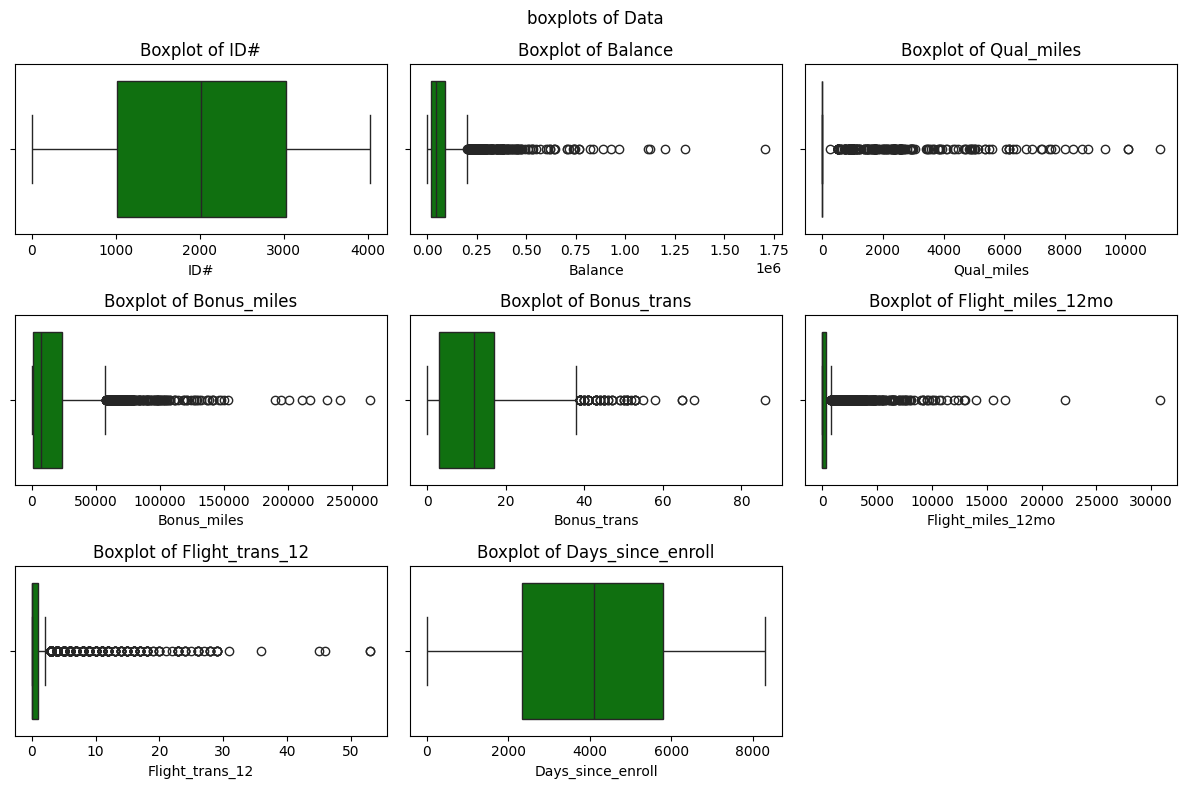

In [15]:
fig,ax = plt.subplots(3,3,figsize=(12,8))

for axis,col in zip(ax.flat,numerical_cols):
  sns.boxplot(data = df,x=col,ax=axis,color="green")
  axis.set_title(f"Boxplot of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("boxplots of Data")
plt.tight_layout()
plt.show()

### Observation :

The boxplots show the presence of significant outliers in several numerical features, particularly **Balance, Qual_miles, Bonus_miles, Bonus_trans, Flight_miles_12mo, and Flight_trans_12**.

Most of these variables are highly right-skewed, indicating that while most customers have relatively low values, a small number of customers have extremely high airline activity or reward-related values.

The **ID#** and **Days_since_enroll** features do not show significant outliers compared to the other numerical variables.

## Histogram Analysis

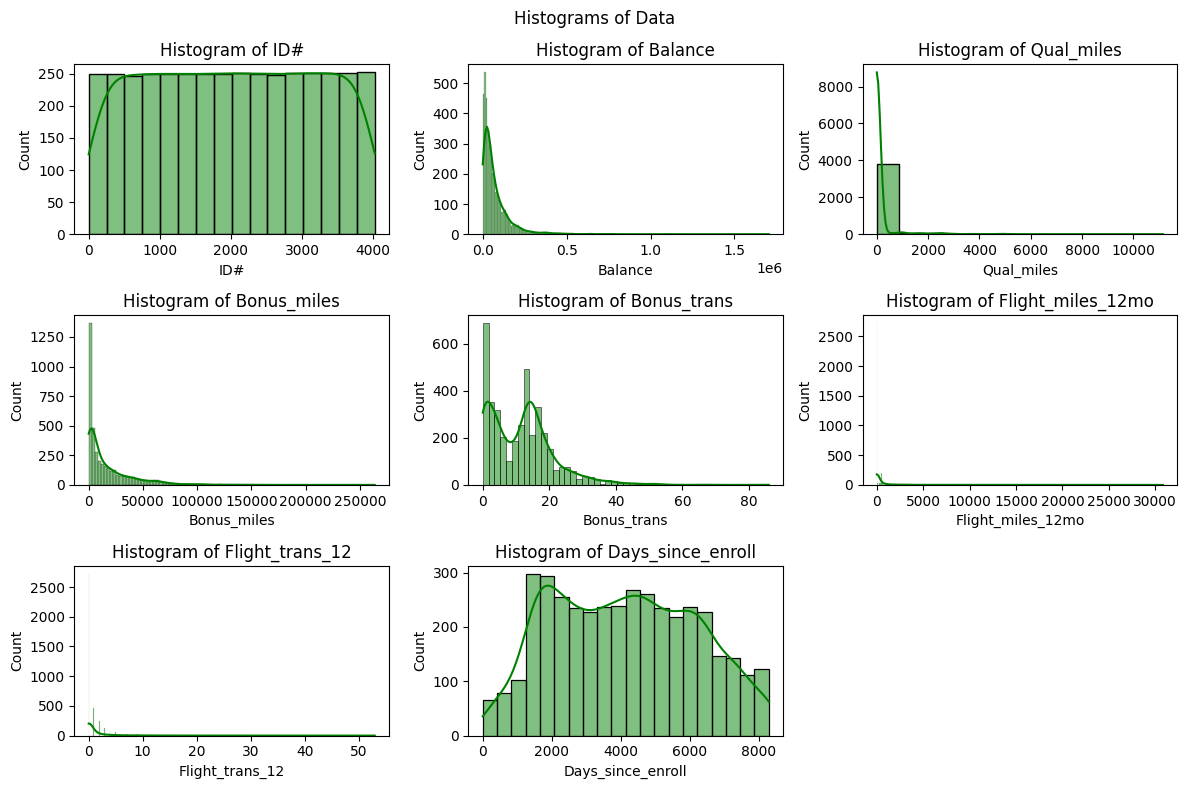

In [16]:
fig,ax = plt.subplots(3,3,figsize=(12,8))
for axis,col in zip(ax.flat,numerical_cols):
  sns.histplot(data = df,x=col,ax=axis,color="green",kde=True)
  axis.set_title(f"Histogram of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("Histograms of Data")
plt.tight_layout()
plt.show()

### Observation:

The histograms show that several numerical features, including **Balance, Qual_miles, Bonus_miles, Flight_miles_12mo, and Flight_trans_12**, are highly right-skewed.

Most customers have relatively low values, while a small number of customers have extremely high values, resulting in long right tails.

**Days_since_enroll** has a comparatively wider distribution, while **Bonus_trans** shows multiple peaks, indicating different groups of customers based on their transaction activity.

The **ID#** variable appears approximately uniformly distributed because it is an identifier rather than a meaningful numerical feature.

## Countplot Analysis

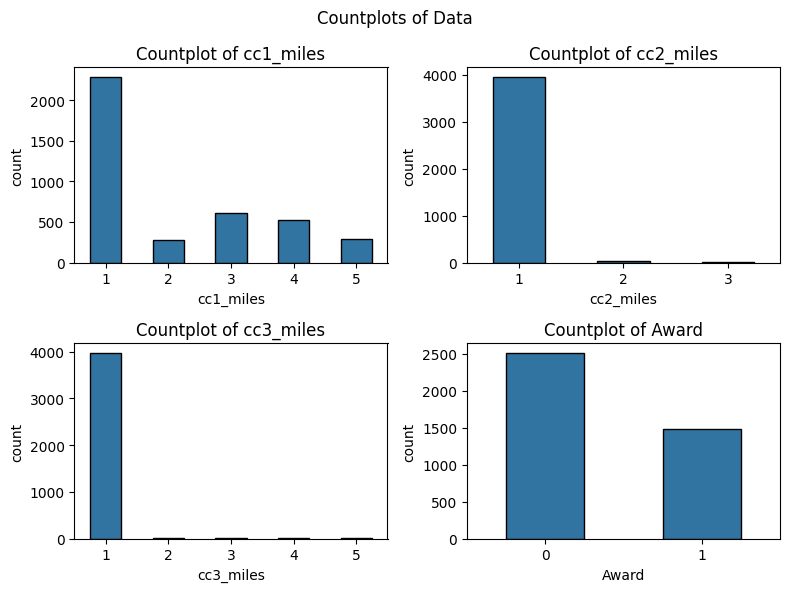

In [17]:
fig,ax = plt.subplots(2,2,figsize=(8,6))
for axis,col in zip(ax.flat,categorical_cols):
  sns.countplot(data = df,x=col,ax=axis,edgecolor="black",width = 0.5)
  axis.set_title(f"Countplot of {col}")
  axis.set_xlabel(col)

plt.suptitle("Countplots of Data")
plt.tight_layout()
plt.show()

### Observation:

The countplots show that the categorical features are not evenly distributed.

For **cc1_miles**, category 1 contains the highest number of customers, followed by categories 3 and 4.

For **cc2_miles** and **cc3_miles**, almost all customers belong to category 1, indicating very limited variation in these features.

The **Award** variable is also imbalanced, with more customers belonging to category 0 than category 1.

## Densityplot or KDEplot

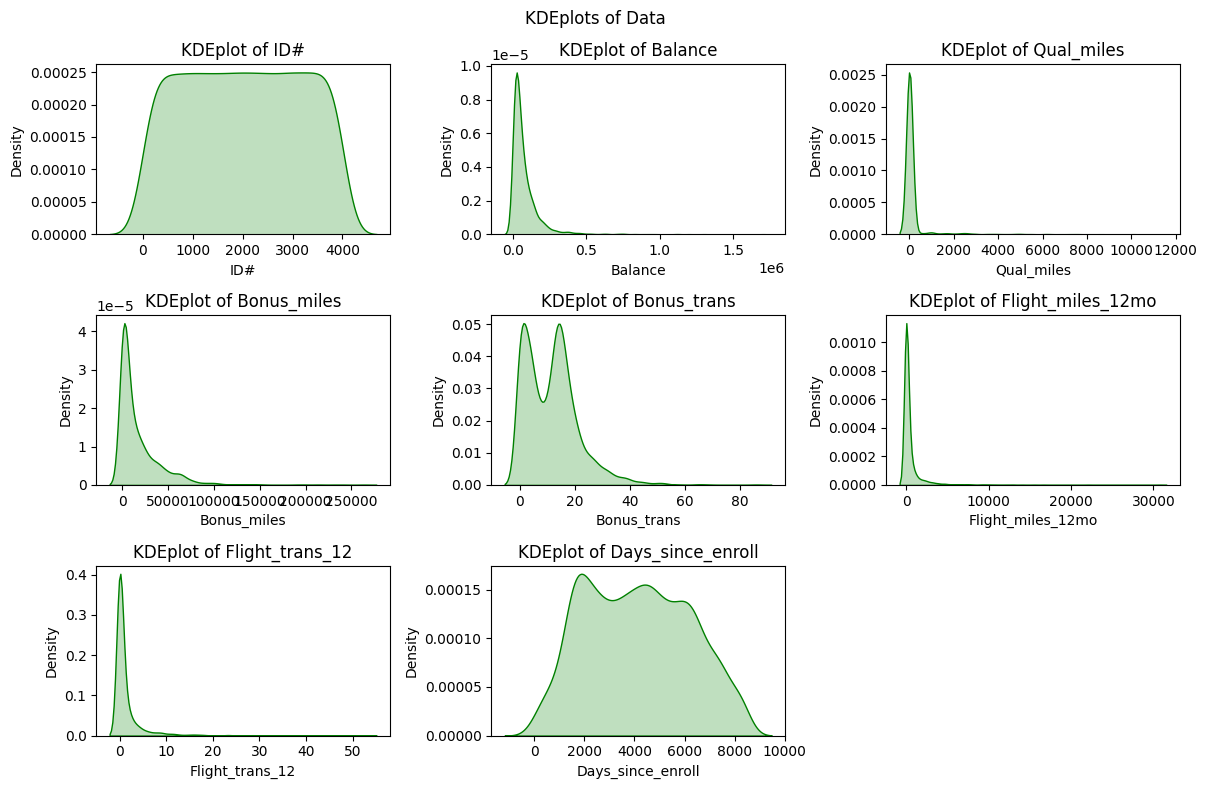

In [18]:
fig,ax = plt.subplots(3,3,figsize=(12,8))

for axis,col in zip(ax.flat,numerical_cols):
  sns.kdeplot(data = df,x=col,ax=axis,color="green",fill=True)
  axis.set_title(f"KDEplot of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("KDEplots of Data")
plt.tight_layout()
plt.show()

### Observation:

The KDE plots confirm that most numerical variables are highly right-skewed.

Features such as **Balance, Qual_miles, Bonus_miles, Flight_miles_12mo, and Flight_trans_12** have a high concentration of observations at lower values and long right tails caused by a small number of high-value customers.

**Bonus_trans** shows multiple peaks, suggesting the presence of different customer groups based on bonus transaction activity.

**Days_since_enroll** has a relatively broader distribution compared to the other features.

# Outliers

## Outlier Handling

## Checking Outliers again

In [19]:
# Remove ID and Award columns
df_cluster = df.drop(columns=["ID#", "Award"]).copy()

# Continuous features for outlier handling
outlier_cols = [
    "Balance",
    "Qual_miles",
    "Bonus_miles",
    "Bonus_trans",
    "Flight_miles_12mo",
    "Flight_trans_12"
]

for col in outlier_cols:

    Q1 = df_cluster[col].quantile(0.25)
    Q3 = df_cluster[col].quantile(0.75)

    IQR = Q3 - Q1

    # Skip IQR clipping if IQR is zero
    if IQR != 0:

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_cluster[col] = df_cluster[col].clip(
            lower=lower_bound,
            upper=upper_bound
        )

In [20]:
outlier_summary_after = {}

for col in df_cluster.columns:

    Q1 = df_cluster[col].quantile(0.25)
    Q3 = df_cluster[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_cluster[col] < lower_bound) |
                (df_cluster[col] > upper_bound)).sum()

    outlier_summary_after[col] = outliers


pd.DataFrame(
    list(outlier_summary_after.items()),
    columns=["Feature", "No_of_Outliers_After"]
)

,Feature,No_of_Outliers_After
0,Balance,0
1,Qual_miles,226
2,cc1_miles,0
3,cc2_miles,43
4,cc3_miles,18
5,Bonus_miles,0
6,Bonus_trans,0
7,Flight_miles_12mo,0
8,Flight_trans_12,0
9,Days_since_enroll,0


## Visualization after handling Outliers

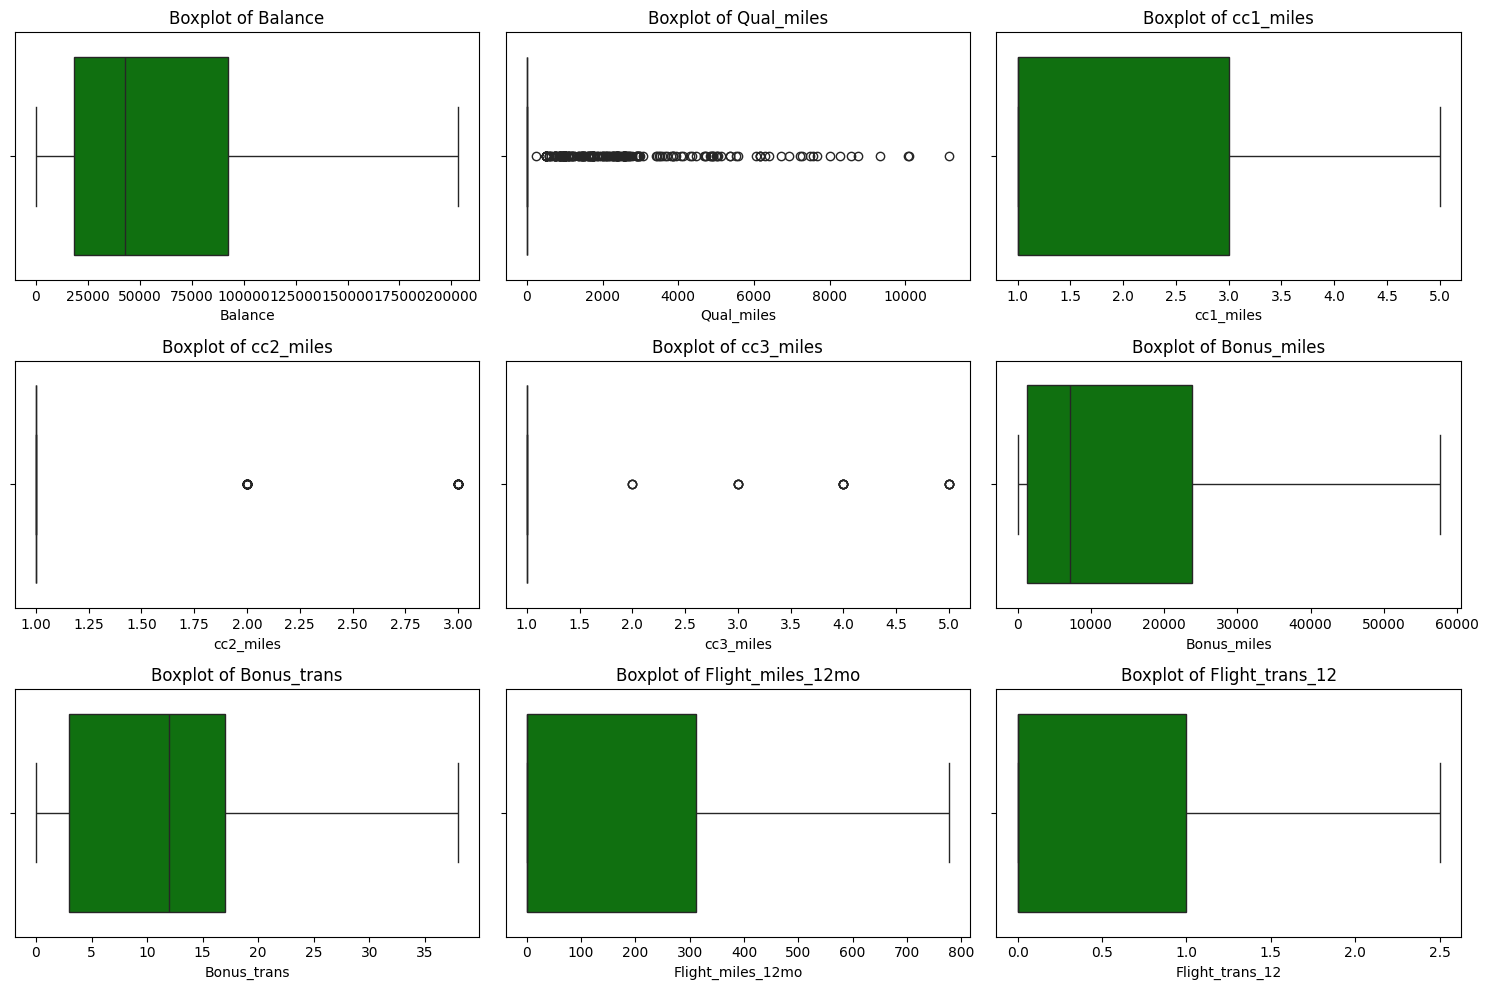

In [21]:
num_cols = df_cluster.columns

fig, ax = plt.subplots(3, 3, figsize=(15, 10))

for axis, col in zip(ax.flat, num_cols):

    sns.boxplot(
        data=df_cluster,
        x=col,
        ax=axis,
        color="green"
    )

    axis.set_title(f"Boxplot of {col}")

# Remove empty subplots
for axis in ax.flat[len(num_cols):]:
    axis.remove()

plt.tight_layout()
plt.show()

## Observation :


The dataset contained several extreme values, particularly in features such as **Balance, Qual_miles, Bonus_miles, Bonus_trans, Flight_miles_12mo, and Flight_trans_12**.

Instead of removing rows containing outliers, the extreme values were capped using the **Interquartile Range (IQR) method**. This approach was chosen because the extreme values may represent genuine high-value or frequent airline customers, which could be important for identifying meaningful clusters.

The **ID#** column was removed because it is only an identifier, and the **Award** column was excluded from the clustering features since clustering is an unsupervised learning technique.

# Correlation Matrix

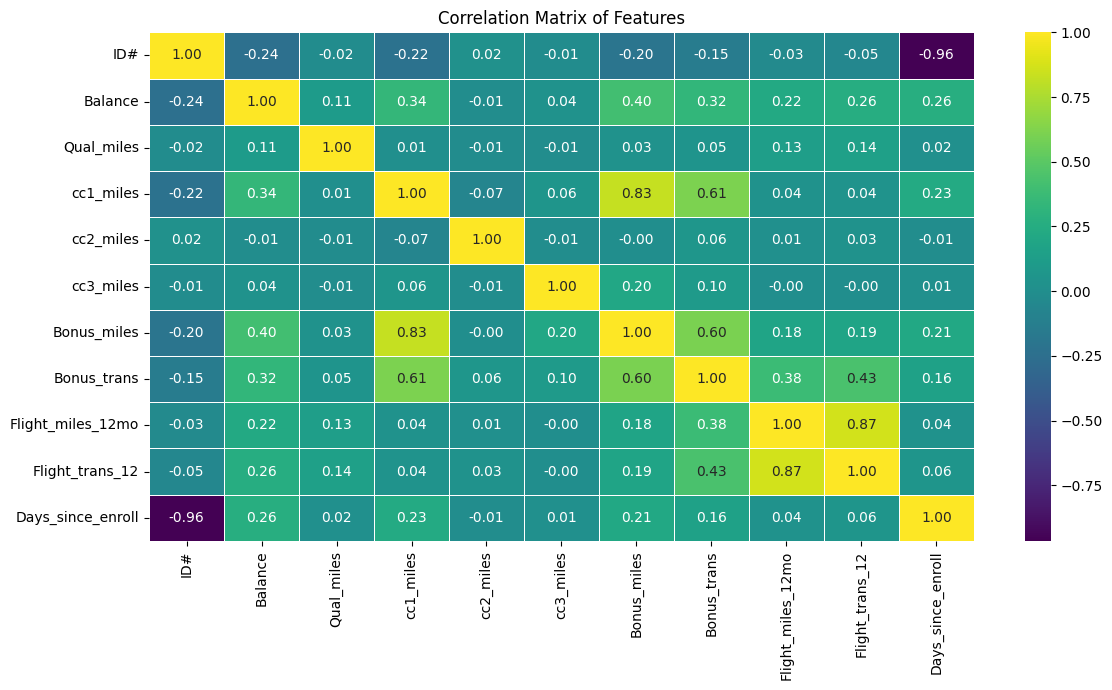

In [22]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    df.drop(columns="Award").corr(),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="viridis"
)

plt.title("Correlation Matrix of Features")

plt.tight_layout()
plt.show()

## Observation:

The correlation matrix shows several meaningful relationships between airline customer activity features.

**cc1_miles and Bonus_miles** have a strong positive correlation of approximately **0.83**, indicating that customers with higher credit card mileage categories tend to accumulate more bonus miles.

**Flight_miles_12mo and Flight_trans_12** have a strong positive correlation of approximately **0.87**, which is expected because customers who fly more frequently generally accumulate more flight miles.

**Bonus_trans** also has moderate positive correlations with **Bonus_miles** and **cc1_miles**.

Most other features show weak correlations, indicating that they provide different information about customer behaviour.

# Data Preprocessing

## Feature and Target separation

In [23]:
X = df_cluster.copy()

### Observation :

Since clustering is an unsupervised learning technique, there is no target variable. The dataset features are used to identify hidden groups or patterns among airline customers.

## Feature Scaling

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled,columns = X.columns)
X_scaled.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.607258,-0.186299,-0.769578,-0.098242,-0.062767,-0.843091,-1.148854,-0.604313,-0.626143,1.395454
1,-0.758947,-0.186299,-0.769578,-0.098242,-0.062767,-0.840822,-1.039133,-0.604313,-0.626143,1.379957
2,-0.382070,-0.186299,-0.769578,-0.098242,-0.062767,-0.624581,-0.819689,-0.604313,-0.626143,1.411920
3,-0.835106,-0.186299,-0.769578,-0.098242,-0.062767,-0.825052,-1.148854,-0.604313,-0.626143,1.372208
4,0.579265,-0.186299,1.409471,-0.098242,-0.062767,1.543191,1.594189,2.034489,2.020176,1.363975


# K-Means

In [25]:
wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

## Elbow Curve

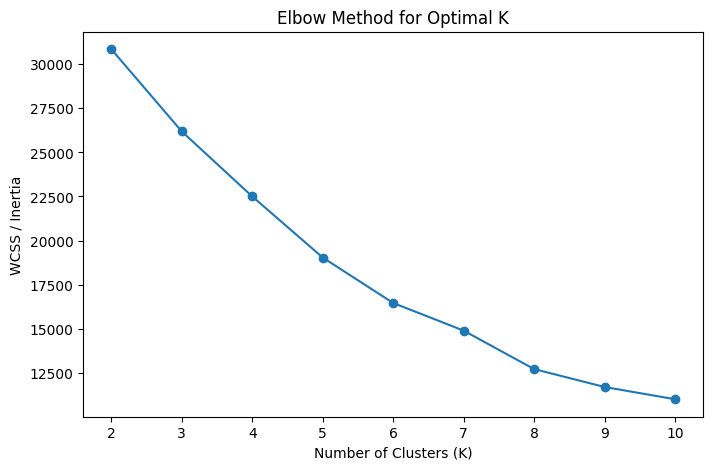

In [26]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(2,11))

plt.show()

### Observation:

The Elbow Method shows that the WCSS decreases continuously as the number of clusters increases. A noticeable reduction in the rate of decrease can be observed around **K = 4**, after which the improvement becomes more gradual.

Although the highest Silhouette Score was obtained at **K = 6**, **K = 4** was selected based on the Elbow Method and the interpretability of the resulting customer segments.

Therefore, **4 clusters** were selected as a reasonable balance between clustering performance and interpretability.

## Silhouette Score for K-Means

In [27]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.3215
K = 3 | Silhouette Score = 0.3073
K = 4 | Silhouette Score = 0.3071
K = 5 | Silhouette Score = 0.3216
K = 6 | Silhouette Score = 0.3345
K = 7 | Silhouette Score = 0.2445
K = 8 | Silhouette Score = 0.2662
K = 9 | Silhouette Score = 0.2649
K = 10 | Silhouette Score = 0.2718


## Final K-Means Model

In [28]:
kmeans = KMeans(
    n_clusters=4,  # Example — choose based on your results
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

## Cluster Visualization

In [29]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

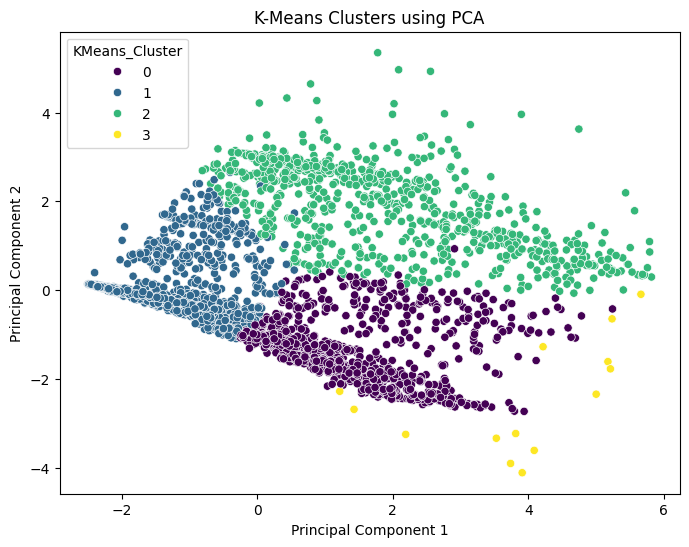

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["KMeans_Cluster"],
    palette="viridis"
)

plt.title("K-Means Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## Observation:

The K-Means clustering visualization using PCA shows the distribution of customers across **4 different clusters**.

The clusters demonstrate different patterns in the two principal components, indicating that the customers can be grouped based on similarities in their airline activity, mileage accumulation, bonus transactions, and other behavioural features.

Although some overlap exists between the clusters, the visualization shows that K-Means was able to identify meaningful groups within the dataset.

The PCA visualization reduces the multidimensional dataset into two dimensions, making the cluster patterns easier to interpret.

# DBSCAN

## DBSCAN Parameter Experimentation

In [31]:
eps_values = [0.5, 1, 1.5, 2]
min_samples_values = [3, 5, 10]

In [32]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

In [33]:
results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        noise_points = list(labels).count(-1)

        results.append([
            eps,
            min_samples,
            n_clusters,
            noise_points
        ])


dbscan_results = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "No_of_Clusters",
        "Noise_Points"
    ]
)

dbscan_results

,eps,min_samples,No_of_Clusters,Noise_Points
0,0.5,3,64,1262
1,0.5,5,30,1523
2,0.5,10,10,1969
3,1.0,3,18,346
4,1.0,5,9,461
5,1.0,10,8,657
6,1.5,3,7,123
7,1.5,5,3,142
8,1.5,10,2,187
9,2.0,3,6,64


## Silhouette Score for DBSCAN

In [34]:
labels = dbscan_labels

# Remove noise points
mask = labels != -1

if len(set(labels[mask])) > 1:

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        labels[mask]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )

else:
    print("Silhouette Score cannot be calculated.")

DBSCAN Silhouette Score: 0.5437


## DBSCAN Visualization

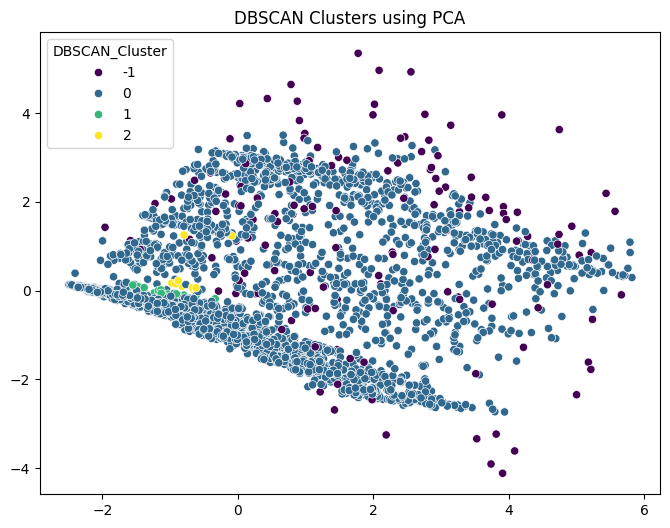

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["DBSCAN_Cluster"],
    palette="viridis"
)

plt.title("DBSCAN Clusters using PCA")

plt.show()

## Observation:

Different combinations of `eps` and `min_samples` were tested to identify suitable parameters for DBSCAN.

Smaller values of `eps` resulted in a large number of clusters and a high number of noise points, indicating excessive fragmentation of the dataset.

As the value of `eps` increased, the number of clusters generally decreased and more observations were assigned to dense clusters.

The combination of **eps = 1.5** and **min_samples = 5** produced **3 clusters** with **142 noise points**, providing a reasonable balance between cluster formation and noise detection. Therefore, these parameters were selected for the final DBSCAN model.

# Final Comparison of Clustering Algorithms

| Algorithm | Number of Clusters | Silhouette Score | Special Feature |
|-----------|-------------------|------------------|-----------------|
| K-Means | 4 | 0.3071 | Produces predefined clusters |
| DBSCAN | 3 | 0.5437 | Detects noise and dense clusters |

# Conclusion:

Both K-Means and DBSCAN were successfully applied to identify hidden patterns within the airline customer dataset.

K-Means provided structured customer segmentation by dividing the customers into a predefined number of groups. The Elbow Method and Silhouette Score were used to evaluate different values of K.

DBSCAN provided stronger cluster separation in this analysis and achieved a higher Silhouette Score. It also identified unusual observations as noise, which is an advantage over K-Means.

Overall, the clustering analysis demonstrates that airline customers can be segmented based on characteristics such as account balance, mileage activity, bonus miles, flight behaviour, and loyalty programme activity.